In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub


/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl


In [3]:
import joblib

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

le = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl"
)

print(X_train.shape)
print(X_test.shape)

(5055991, 77)
(1263998, 77)


In [4]:
from catboost import CatBoostClassifier

In [5]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=100
)

cat.fit(X_train, y_train)

0:	learn: 2.0750810	total: 41s	remaining: 3h 24m 4s
100:	learn: 0.0858693	total: 1h 8m 4s	remaining: 2h 14m 8s
200:	learn: 0.0724546	total: 2h 15m 19s	remaining: 1h 6m 39s
299:	learn: 0.0688835	total: 3h 21m 57s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='MultiClass', iterations=300, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [6]:
y_pred = cat.predict(X_test)

# CatBoost returns shape (n,1)
y_pred = y_pred.astype(int).flatten()

y_prob = cat.predict_proba(X_test)

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.9816
Precision: 0.9759
Recall   : 0.9816
F1-score : 0.9735
MCC      : 0.9492
AUC      : 0.9901


In [8]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

print(classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.98      1.00      0.99    998829
                     Bot       1.00      0.99      1.00     28907
        Brute Force -Web       0.98      0.48      0.64       111
        Brute Force -XSS       1.00      0.58      0.73        45
        DDOS attack-HOIC       1.00      1.00      1.00     39772
    DDoS attack-LOIC-UDP       0.83      0.95      0.89       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       0.99      1.00      1.00     29040
DoS attacks-SlowHTTPTest       0.44      0.64      0.52        11
   DoS attacks-Slowloris       0.98      0.99      0.98      1982
          FTP-BruteForce       0.33      0.10      0.15        10
            Infiltration       0.65      0.03      0.05     22764
           SQL Injection       1.00      0.47      0.64        17
         

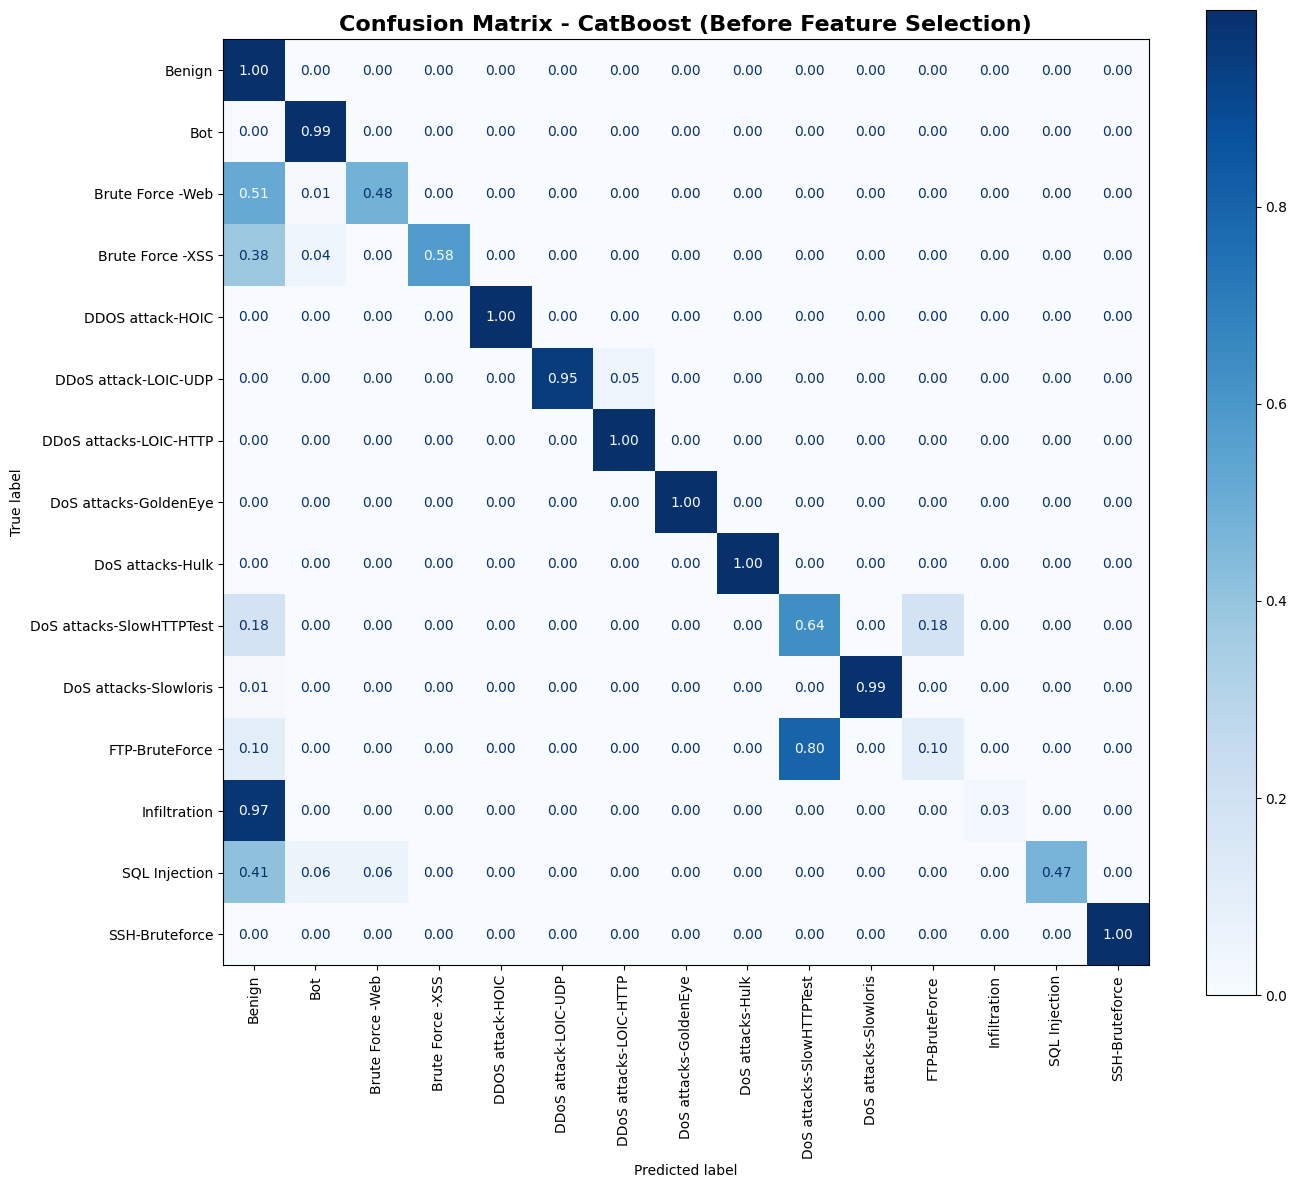

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - CatBoost (Before Feature Selection)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()

plt.show()

In [10]:
import os

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [11]:
import joblib

joblib.dump(
    cat,
    "outputs/models/catboost.pkl"
)

print("catboost model saved!")

catboost model saved!


In [12]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["CatBoost"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "MCC": [mcc],
    "AUC": [auc]
})

metrics_df.to_csv(
    "outputs/results/catb_metrics.csv",
    index=False
)

print(metrics_df)

      Model  Accuracy  Precision    Recall        F1       MCC       AUC
0  CatBoost  0.981601   0.975901  0.981601  0.973464  0.949153  0.990054


In [13]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]
report = classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/results/catb_classification_report.csv"
)

print("Classification Report Saved!")

Classification Report Saved!


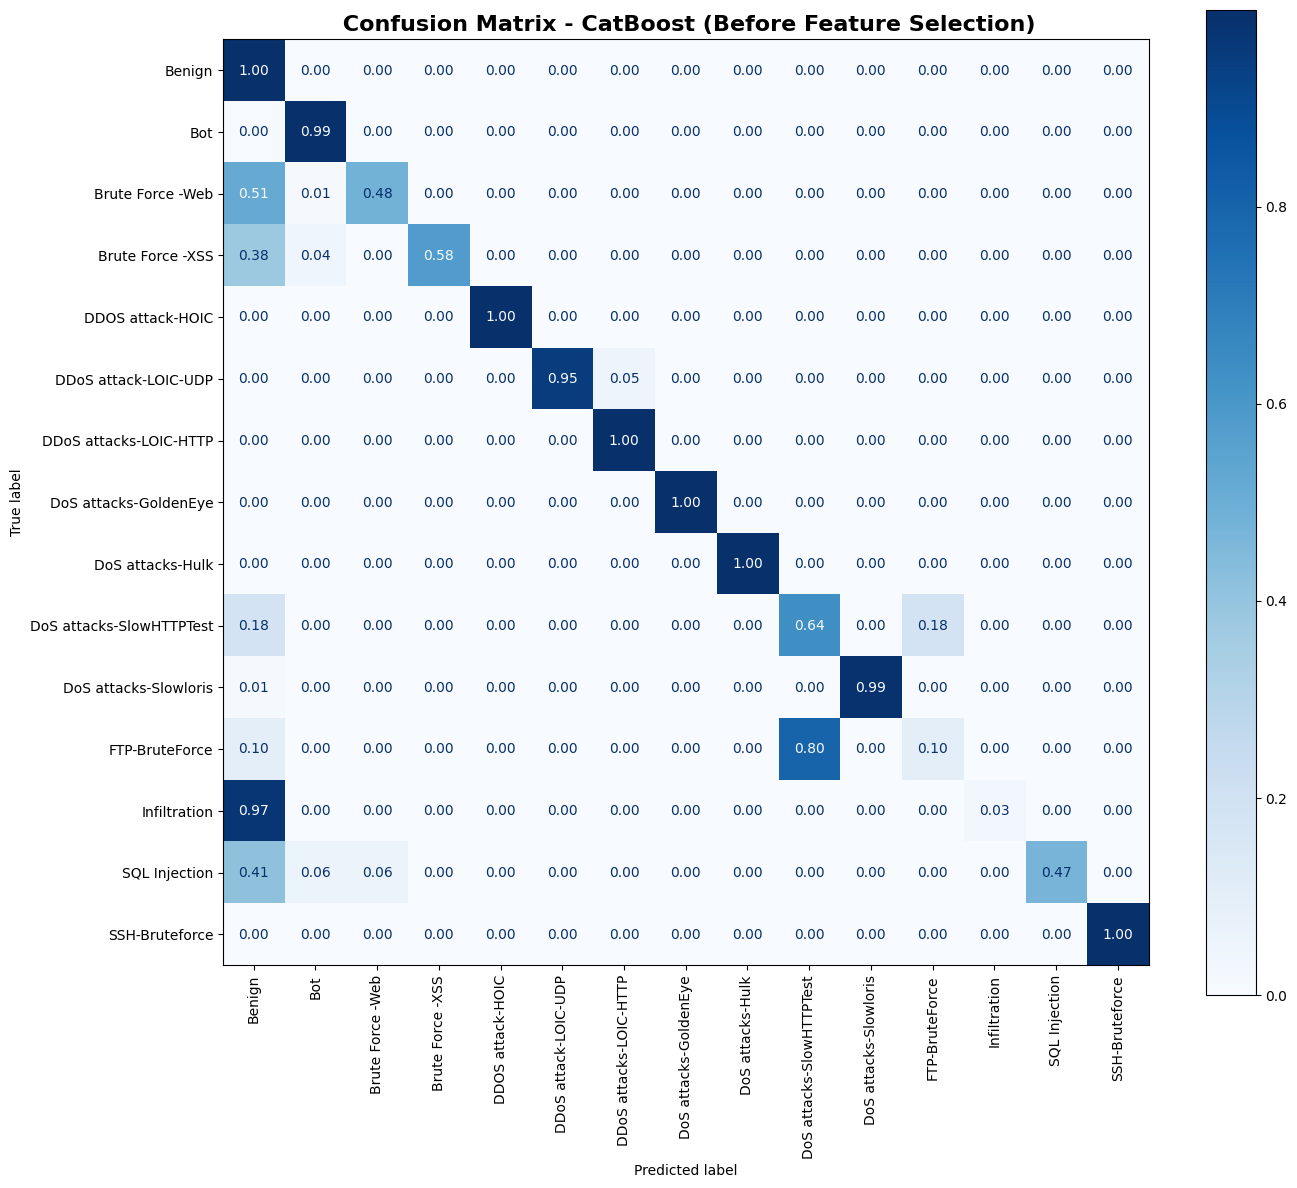

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    " Confusion Matrix - CatBoost (Before Feature Selection)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/results/catb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()